# EDA for New Occurrence Data

"pt" = Permian-Triassic = Perm_Trias folder

"gl" = Guadilupian-Ladinian = Guad-Ladin folder

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Permian-Triassic Data


## Loading + Filtering + EDA Occs Data

In [3]:
pt_reptilia_all = pd.read_excel("Perm-Trias/occs_combined/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_All_AF_Tiago_combined.xlsx")
pt_reptilia_terr = pd.read_excel("Perm-Trias/occs_combined/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_terres_AF_Tiago_combined.xlsx")
pt_synapsida = pd.read_excel("Perm-Trias/occs_combined/synapsida_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_AF_Tiago_combined.xlsx")

# gl_reptilia = pd.read_excel("Guad-Ladin/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_terres_MidTria.xlsx")
# gl_synapsida = pd.read_excel("Guad-Ladin/synapsida_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_MidTria.xlsx")

In [4]:
pt_reptilia_all.columns

Index(['occurrence_no', 'occurrence_no_AF', 'id', 'id_seperated', 'expt',
       'Rotated latitude', 'Rotated longitude', 'i_index', 'j_index',
       'Topo. (m)',
       ...
       'geoplate', 'paleoage', 'paleolng', 'paleolat', 'paleomodel2',
       'geoplate2', 'paleoage2', 'paleolng2', 'paleolat2', 'paleomodel3'],
      dtype='object', length=296)

In [5]:

pt_reptilia_all_filtered = pt_reptilia_all[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]
pt_reptilia_terr_filtered = pt_reptilia_terr[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]
pt_synapsida_filtered = pt_synapsida[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]

# Need to add 'id' back in
# gl_reptilia_filtered = gl_reptilia[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min']]
# gl_synapsida_filtered = gl_synapsida[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min']]

In [6]:
list_filtered_dfs = [pt_reptilia_all_filtered, pt_reptilia_terr_filtered, pt_synapsida_filtered]
                        # ,gl_reptilia_filtered, gl_synapsida_filtered]

list_filtered_dfs_names = ['pt_reptilia_all_filtered', 'pt_reptilia_terr_filtered', 'pt_synapsida_filtered']
                        # ,'gl_reptilia_filtered', 'gl_synapsida_filtered']

# write a loop for 0:len(list_filtered_dfs) to print the name of each dataframe and its description
# and the number of missing values in each column
for i in range(len(list_filtered_dfs)):
    print(f"DataFrame: {list_filtered_dfs_names[i]}")
    print(list_filtered_dfs[i].describe())
    print(list_filtered_dfs[i].isna().sum())
    # Check that occurrence_no_AF is the same as occurrence_no, because the former came from Alex's dataset and the latter from Tiago's dataset.
    # If they're the same we know merging the two datasets happened correctly.
    different_rows = list_filtered_dfs[i].loc[list_filtered_dfs[i]['occurrence_no'] != list_filtered_dfs[i]['occurrence_no_AF']]
    length_different_rows = different_rows.shape[0]
    print(f"Number of rows where 'occurrence_no' and 'occurrence_no_AF' are different: {length_different_rows}")


DataFrame: pt_reptilia_all_filtered
               id  Rotated latitude      age_max      age_min
count  3987.00000       3987.000000  3987.000000  3987.000000
mean   5134.00000        -71.255378   244.115497   234.918219
std    1151.09209        820.651838    22.017241    24.675819
min    3141.00000      -9999.000000   201.400000   199.500000
25%    4137.50000        -47.039270   227.000000   208.500000
50%    5134.00000          1.353064   242.000000   237.000000
75%    6130.50000         27.011270   259.510000   251.902000
max    7127.00000         61.323520   298.900000   293.520000
id                  0
occurrence_no       0
occurrence_no_AF    0
Rotated latitude    0
genus               0
age_max             0
age_min             0
Epoch               0
dtype: int64
Number of rows where 'occurrence_no' and 'occurrence_no_AF' are different: 0
DataFrame: pt_reptilia_terr_filtered
                id  Rotated latitude      age_max      age_min
count  3140.000000       3140.000000  31

## Ages Visualization (Range Plots)

In [ ]:
# Custom function to plot age RANGE (x) frequency (y) with log scale
def range_plot(df, df_name):
    # # Count the frequency of each age range
    # df['range'] = df.apply(lambda row: (row['age_max'], row['age_min']), axis=1)
    # frequency = df['range'].value_counts().sort_index()

    # Determine which column names are present
    age_max_col = 'age_max'
    age_min_col = 'age_min' 
    
    # Count the frequency of each age range
    df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)
    frequency = df['range'].value_counts().sort_index()
    # Create the plot
    fig, ax = plt.subplots(figsize=(12,6))

    # Plot each range as a horizontal line with log-transformed y-values
    for (age_min, age_max), count in frequency.items():
        ax.plot([age_min, age_max], [np.log(count)] * 2, 'b-', linewidth=2)

    # Set the axis labels and title
    ax.set_xlabel('Age')
    ax.set_ylabel('Log(Frequency)')
    ax.set_title(f'{df_name} Age Range Frequency Plot (Log Scale)')

    # Get the x-axis limits
    x_min, x_max = ax.get_xlim()

    # Create ticks for every 1 unit
    ticks = np.arange(np.ceil(x_min), np.floor(x_max) + 1, 1)
    ax.set_xticks(ticks)

    # Create labels for every 5 units
    labels = [str(int(x)) if x % 5 == 0 else '' for x in ticks]
    ax.set_xticklabels(labels)

    # Invert the x-axis
    ax.invert_xaxis()

    # Add horizontal line at y=log(10)
    ax.axhline(y=np.log(10), color='r', linestyle='--', linewidth=2)

    # Customize y-axis ticks to show original frequency values
    y_ticks = ax.get_yticks()
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{np.exp(y):.0f}' for y in y_ticks])

    # Add vertical lines at the time-bin x-values
    vertical_lines = [290.1, 283.5, 273, 264.3, 259.5, 252, 247, 242, 237, 227, 217, 208]
    for vline in vertical_lines:
        ax.axvline(x=vline, color='g', linestyle='--', linewidth=1)

    # Show the plot
    plt.tight_layout()
    plt.show()
    plt.close()

    return fig

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_23540\1700410389.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


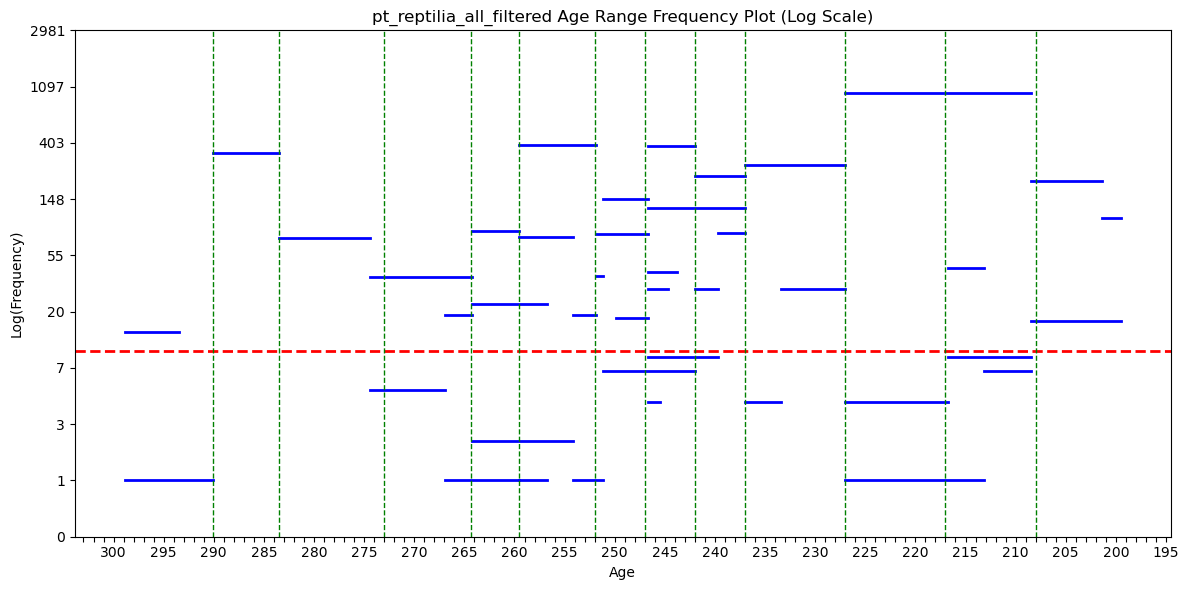

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_23540\1700410389.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


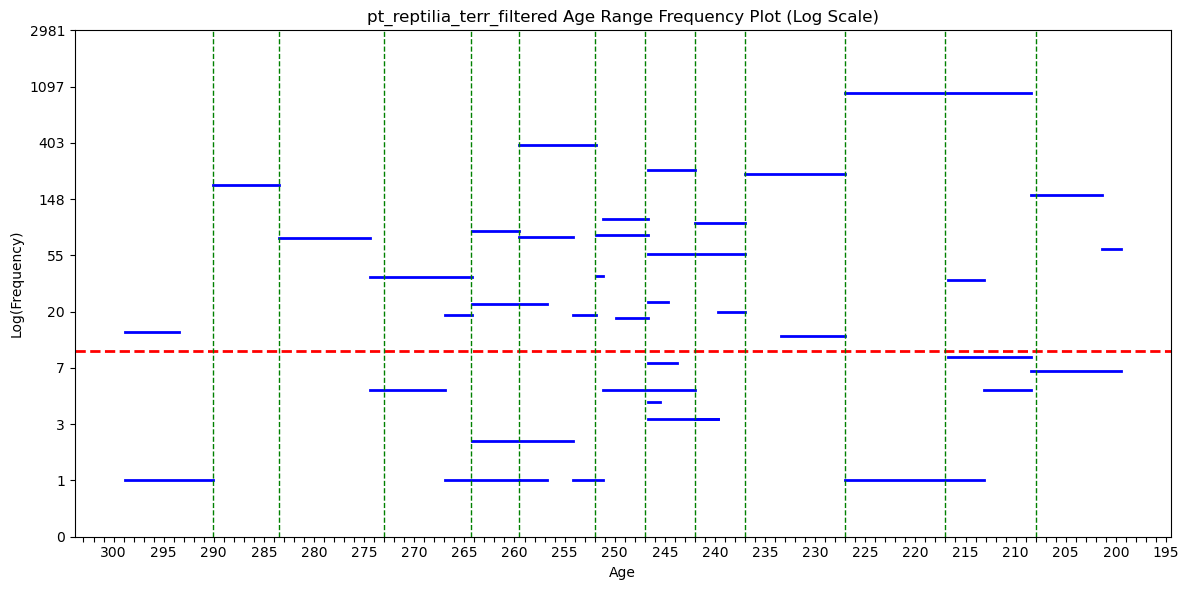

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_23540\1700410389.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


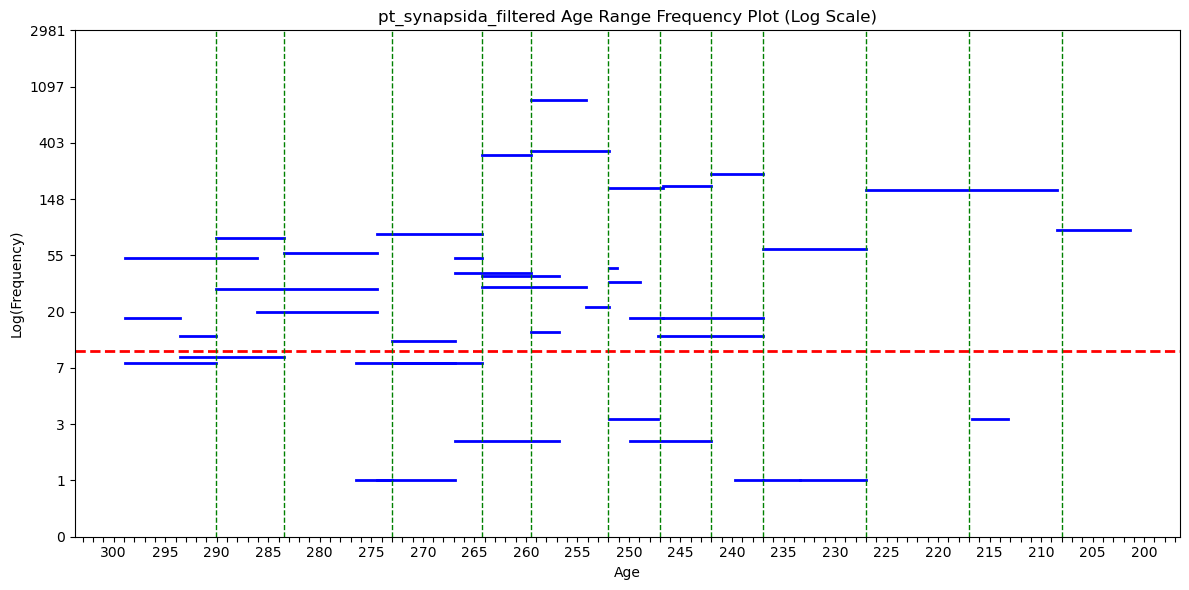

In [ ]:
for i in range(len(list_filtered_dfs)):
    range_plot(list_filtered_dfs[i], list_filtered_dfs_names[i])

## Dropping non-letter 'genus' strings

In [7]:
# See if there are any non-letters in the 'genus' columns of each dataframe
for i in range(len(list_filtered_dfs)):
    non_letters = list_filtered_dfs[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names[i]}")
        print(f"Non-letter characters found in 'genus': {list_filtered_dfs[i][non_letters]['genus'].unique()}\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered
Non-letter characters found in 'genus': ['new Neotheropoda' 'new Rhynchocephalia' 'Stenoscelida\xa0']

DataFrame: pt_reptilia_terr_filtered
Non-letter characters found in 'genus': ['new Neotheropoda' 'new Rhynchocephalia' 'Stenoscelida\xa0']

DataFrame: pt_synapsida_filtered
Non-letter characters found in 'genus': ['-' 'Bonacynodon ']



In [8]:
# print the rows with non-letter characters in the 'genus' column
for i in range(len(list_filtered_dfs)):
    non_letters = list_filtered_dfs[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names[i]}")
        print(list_filtered_dfs[i][non_letters])
        print("\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered
       id occurrence_no occurrence_no_AF  Rotated latitude  \
974  4115          N363             N363         -46.11636   
975  4116          N364             N364         -46.11636   
979  4120          N503             N503         -46.11636   

                   genus  age_max  age_min           Epoch  
974     new Neotheropoda    227.0    208.5  Upper Triassic  
975  new Rhynchocephalia    227.0    208.5  Upper Triassic  
979        Stenoscelida     227.0    208.5  Upper Triassic  


DataFrame: pt_reptilia_terr_filtered
      id occurrence_no occurrence_no_AF  Rotated latitude  \
968  969          N363             N363         -46.11636   
969  970          N364             N364         -46.11636   
973  974          N503             N503         -46.11636   

                   genus  age_max  age_min           Epoch  
968     new Neotheropoda    227.0    208.5  Upper Triassic  
969  new Rhynchocephalia    227.0    208.5  Upper Triassic  
973 

In [9]:
# Fixing those

# Make a copy of the filtered dataframes to avoid modifying the original ones
pt_reptilia_all_filtered_spellchecked = pt_reptilia_all_filtered.copy()
pt_reptilia_terr_filtered_spellchecked = pt_reptilia_terr_filtered.copy()
pt_synapsida_filtered_spellchecked = pt_synapsida_filtered.copy()

# Now perform all the cleaning

# Strip the ending space from row with index 979 in pt_reptilia_all_filtered in 'genus' column
pt_reptilia_all_filtered_spellchecked.at[979, 'genus'] = pt_reptilia_all_filtered_spellchecked.at[979, 'genus'].strip()

# Strip the ending space from row with index 973 in pt_reptilia_terr_filtered in 'genus' column
pt_reptilia_terr_filtered_spellchecked.at[973, 'genus'] = pt_reptilia_terr_filtered_spellchecked.at[973, 'genus'].strip()

# Strip the ending space from row with index 2685 and 2686 in pt_synapsida_filtered in 'genus' column
pt_synapsida_filtered_spellchecked.at[2685, 'genus'] = pt_synapsida_filtered_spellchecked.at[2685, 'genus'].strip()
pt_synapsida_filtered_spellchecked.at[2686, 'genus'] = pt_synapsida_filtered_spellchecked.at[2686, 'genus'].strip()

# Delete row with index 370 from pt_synapsida_all_filtered
pt_synapsida_filtered_spellchecked = pt_synapsida_filtered_spellchecked.drop(370)



In [10]:
# Check again

list_filtered_dfs_spellchecked = [pt_reptilia_all_filtered_spellchecked, pt_reptilia_terr_filtered_spellchecked, pt_synapsida_filtered_spellchecked]
list_filtered_dfs_names_spellchecked = ['pt_reptilia_all_filtered_spellchecked', 'pt_reptilia_terr_filtered_spellchecked', 'pt_synapsida_filtered_spellchecked']

# print the rows with non-letter characters in the 'genus' column
for i in range(len(list_filtered_dfs_spellchecked)):
    non_letters = list_filtered_dfs_spellchecked[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names_spellchecked[i]}")
        print(list_filtered_dfs_spellchecked[i][non_letters])
        print("\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names_spellchecked[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered_spellchecked
       id occurrence_no occurrence_no_AF  Rotated latitude  \
974  4115          N363             N363         -46.11636   
975  4116          N364             N364         -46.11636   

                   genus  age_max  age_min           Epoch  
974     new Neotheropoda    227.0    208.5  Upper Triassic  
975  new Rhynchocephalia    227.0    208.5  Upper Triassic  


DataFrame: pt_reptilia_terr_filtered_spellchecked
      id occurrence_no occurrence_no_AF  Rotated latitude  \
968  969          N363             N363         -46.11636   
969  970          N364             N364         -46.11636   

                   genus  age_max  age_min           Epoch  
968     new Neotheropoda    227.0    208.5  Upper Triassic  
969  new Rhynchocephalia    227.0    208.5  Upper Triassic  


DataFrame: pt_synapsida_filtered_spellchecked - No non-letter characters found in 'genus'.



## PT Latitude -9999 Cleaning


In [ ]:
pt_reptilia_all_filtered_spellchecked_lats = pt_reptilia_all_filtered_spellchecked.copy()
pt_reptilia_terr_filtered_spellchecked_lats = pt_reptilia_terr_filtered_spellchecked.copy()
pt_synapsida_filtered_spellchecked_lats = pt_synapsida_filtered_spellchecked.copy()


In [22]:
# Checking for nonsense values in the 'Rotated latitude' column
pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'].describe(), pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'].describe(), pt_synapsida_filtered_spellchecked_lats['Rotated latitude'].describe()

(               id  Rotated latitude
 count  3987.00000       3987.000000
 mean   5134.00000        -71.255378
 std    1151.09209        820.651838
 min    3141.00000      -9999.000000
 25%    4137.50000        -47.039270
 50%    5134.00000          1.353064
 75%    6130.50000         27.011270
 max    7127.00000         61.323520,
                 id  Rotated latitude
 count  3140.000000       3140.000000
 mean   1570.500000        -23.135116
 std     906.584249        400.134800
 min       1.000000      -9999.000000
 25%     785.750000        -49.043510
 50%    1570.500000          1.353064
 75%    2355.250000         24.956070
 max    3140.000000         61.323520,
                  id  Rotated latitude
 count   3184.000000       3184.000000
 mean    8720.383794        -45.700334
 std      919.463907        308.060852
 min     7128.000000      -9999.000000
 25%     7924.750000        -61.365010
 50%     8720.500000        -52.001180
 75%     9516.250000        -15.491353
 max    103

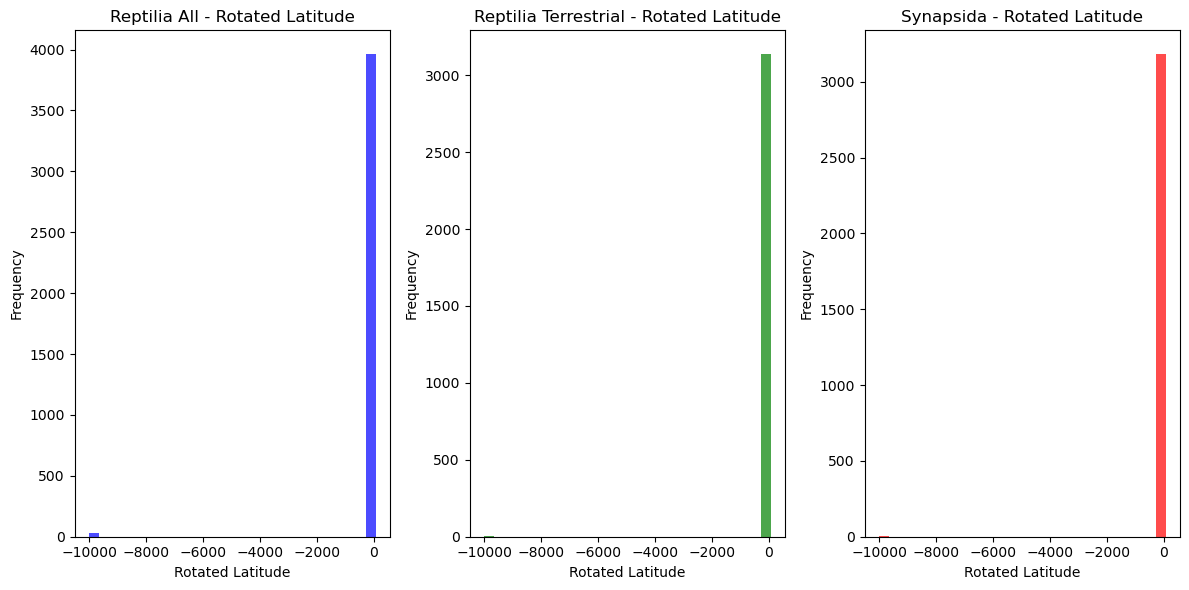

In [19]:
# Visualizing the latitudes
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='blue', alpha=0.7)
plt.title('Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)    
plt.hist(pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='green', alpha=0.7)
plt.title('Reptilia Terrestrial - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
plt.hist(pt_synapsida_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='red', alpha=0.7)
plt.title('Synapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Perm-Trias/bdnn_trait_files/raw_rotated_latitude_histograms.png')
plt.show()

In [23]:
# Viewing the rows whose latitudes are = -9999
print("Rows with 'Rotated latitude' = -9999 in pt_reptilia_all_filtered_spellchecked_lats:")
print(pt_reptilia_all_filtered_spellchecked_lats[pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'] == -9999])
print("\nRows with 'Rotated latitude' = -9999 in pt_reptilia_terr_filtered_spellchecked_lats:")
print(pt_reptilia_terr_filtered_spellchecked_lats[pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'] == -9999])
print("\nRows with 'Rotated latitude' = -9999 in pt_synapsida_filtered_spellchecked_lats:")
print(pt_synapsida_filtered_spellchecked_lats[pt_synapsida_filtered_spellchecked_lats['Rotated latitude'] == -9999])


Rows with 'Rotated latitude' = -9999 in pt_reptilia_all_filtered_spellchecked_lats:
        id            genus  Rotated latitude
691   3832     Shastasaurus           -9999.0
1068  4209   Neusticosaurus           -9999.0
1069  4210     Cymatosaurus           -9999.0
1340  4481  Californosaurus           -9999.0
1346  4487      Nectosaurus           -9999.0
1347  4488      Nectosaurus           -9999.0
1348  4489     Shastasaurus           -9999.0
1349  4490   Thalattosaurus           -9999.0
1368  4509      Nectosaurus           -9999.0
1383  4524     Shastasaurus           -9999.0
1384  4525     Shastasaurus           -9999.0
1385  4526  Californosaurus           -9999.0
1466  4607    Gracilicollum           -9999.0
1957  5098    Termatosaurus           -9999.0
1958  5099    Ichthyosaurus           -9999.0
1959  5100    Termatosaurus           -9999.0
1960  5101    Ichthyosaurus           -9999.0
2155  5296       Meroktenos           -9999.0
2513  5654   Thalattosaurus           -999

In [25]:
# After checking with Tiago, we decided to drop the rows with 'Rotated latitude' = -9999
pt_reptilia_all_filtered_spellchecked_lats_dropped = pt_reptilia_all_filtered_spellchecked_lats[pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'] != -9999]
pt_reptilia_terr_filtered_spellchecked_lats_dropped = pt_reptilia_terr_filtered_spellchecked_lats[pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'] != -9999]
pt_synapsida_filtered_spellchecked_lats_dropped = pt_synapsida_filtered_spellchecked_lats[pt_synapsida_filtered_spellchecked_lats['Rotated latitude'] != -9999]

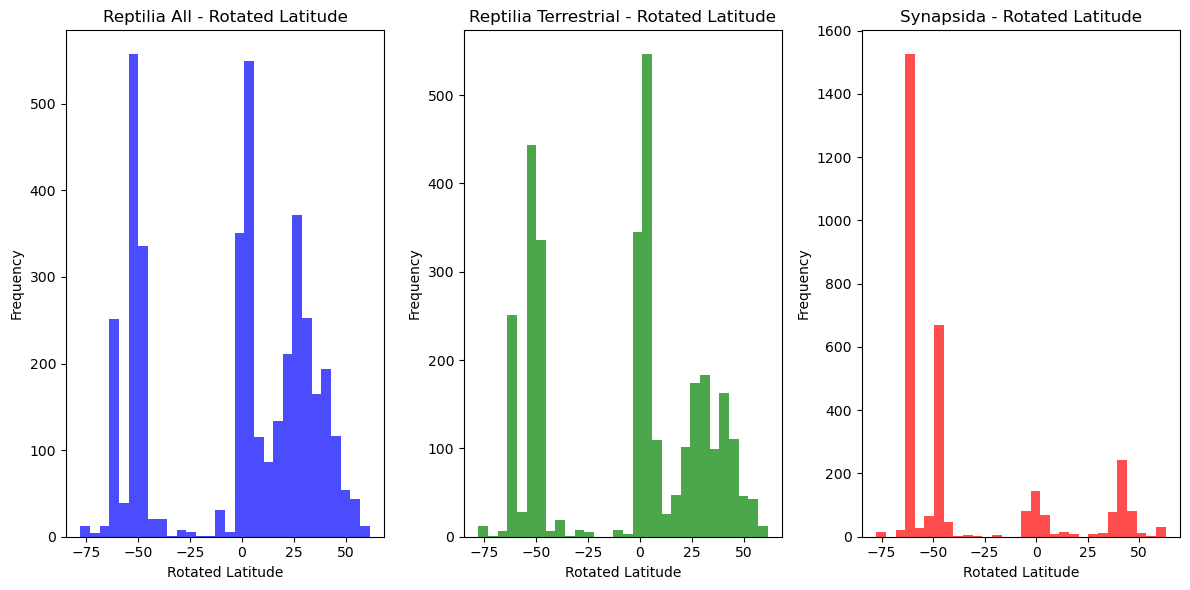

In [26]:
# Visualizing the latitudes now, after having dropped the -9999 values
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(pt_reptilia_all_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='blue', alpha=0.7)
plt.title('Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)    
plt.hist(pt_reptilia_terr_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='green', alpha=0.7)
plt.title('Reptilia Terrestrial - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
plt.hist(pt_synapsida_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='red', alpha=0.7)
plt.title('Synapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Perm-Trias/bdnn_trait_files/cleaned_rotated_latitude_histograms.png')
plt.show()

In [ ]:
# Save the cleaned dataframes to new Excel files
pt_reptilia_all_filtered_spellchecked_lats_dropped.to_excel("Perm-Trias/occs_combined/pt_reptilia_all_cleaned.csv", index=False)
pt_reptilia_terr_filtered_spellchecked_lats_dropped.to_excel("Perm-Trias/occs_combined/pt_reptilia_terr_cleaned.csv", index=False)
pt_synapsida_filtered_spellchecked_lats_dropped.to_excel("Perm-Trias/occs_combined/pt_synapsida_cleaned.csv", index=False)

## Saving Non-Lat Binned PT Occs off as PyRate Input .txts

Saving off data frames up until now, b/c all the rows that need to be dropped have been dropped

All that's left is latitude binning, which is only needed for models we're running that have predictors. No additional rows will be created or dropped in that section

In [ ]:
# If you want to read it in instead of running all above again, uncomment the following lines:
# pt_reptilia_all_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_all_cleaned.csv")
# pt_reptilia_terr_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_terr_cleaned.csv")
# pt_synapsida_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_combined/pt_synapsida_cleaned.csv")

In [ ]:
cols_dict = {'genus':'Species', 'age_max':'max_age', 'age_min':'min_age'}

pt_reptilia_all_pyrate_input_txt = pt_reptilia_all_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_reptilia_all_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_reptilia_all_pyrate_input_txt = pt_reptilia_all_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]



pt_reptilia_terr_pyrate_input_txt = pt_reptilia_terr_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_reptilia_terr_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_reptilia_terr_pyrate_input_txt = pt_reptilia_terr_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]



pt_synapsida_pyrate_input_txt = pt_synapsida_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_synapsida_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_synapsida_pyrate_input_txt = pt_synapsida_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]

In [ ]:
# Only the synapsida dataset should have one fewer row
# All other datasets should have the same number of rows as before
pt_reptilia_all_filtered.shape[0], pt_reptilia_all_pyrate_input_txt.shape[0], pt_reptilia_terr_filtered.shape[0], pt_reptilia_terr_pyrate_input_txt.shape[0], pt_synapsida_filtered.shape[0], pt_synapsida_pyrate_input_txt.shape[0]

(3987, 3987, 3140, 3140, 3185, 3184)

In [ ]:
pt_reptilia_all_pyrate_input_txt.isna().sum(), pt_reptilia_terr_pyrate_input_txt.isna().sum(), pt_synapsida_pyrate_input_txt.isna().sum()

(Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64)

In [ ]:
pt_reptilia_all_pyrate_input_txt.head(), pt_reptilia_terr_pyrate_input_txt.head(), pt_synapsida_pyrate_input_txt.head()

(          Species   Status  min_age  max_age
 0     Icarosaurus  extinct    208.5    227.0
 1        Rutiodon  extinct    208.5    227.0
 2  Trilophosaurus  extinct    208.5    227.0
 3     Postosuchus  extinct    208.5    227.0
 4     Postosuchus  extinct    208.5    227.0,
       Species   Status  min_age  max_age
 0  Vancleavea  extinct    208.5    227.0
 1  Vancleavea  extinct    208.5    227.0
 2  Vancleavea  extinct    208.5    227.0
 3  Vancleavea  extinct    208.5    227.0
 4  Vancleavea  extinct    208.5    227.0,
         Species   Status  min_age  max_age
 0    Dimetrodon  extinct    286.1    298.9
 1    Ophiacodon  extinct    286.1    298.9
 2   Sphenacodon  extinct    286.1    298.9
 3  Edaphosaurus  extinct    286.1    298.9
 4    Ophiacodon  extinct    286.1    298.9)

In [ ]:
# Check data types
print(pt_reptilia_all_pyrate_input_txt.dtypes)
print(pt_reptilia_terr_pyrate_input_txt.dtypes)
print(pt_synapsida_pyrate_input_txt.dtypes)

Species     object
Status      object
min_age    float64
max_age    float64
dtype: object
Species     object
Status      object
min_age    float64
max_age    float64
dtype: object
Species     object
Status      object
min_age    float64
max_age    float64
dtype: object


In [ ]:
# Check if min_age is ever greater than max_age
print("Checking if min_age is ever greater than max_age in pt_reptilia_all_pyrate_input_txt:")
print((pt_reptilia_all_pyrate_input_txt['min_age'] > pt_reptilia_all_pyrate_input_txt['max_age']).any())
print("Checking if min_age is ever greater than max_age in pt_reptilia_terr_pyrate_input_txt:")
print((pt_reptilia_terr_pyrate_input_txt['min_age'] > pt_reptilia_terr_pyrate_input_txt['max_age']).any())
print("Checking if min_age is ever greater than max_age in pt_synapsida_pyrate_input_txt:")
print((pt_synapsida_pyrate_input_txt['min_age'] > pt_synapsida_pyrate_input_txt['max_age']).any())


Checking if min_age is ever greater than max_age in pt_reptilia_all_filtered_spellchecked_renamed:
False
Checking if min_age is ever greater than max_age in pt_reptilia_terr_filtered_spellchecked_renamed:
False
Checking if min_age is ever greater than max_age in pt_synapsida_filtered_spellchecked_renamed:
False


In [ ]:
# Saving all off as .txt's
pt_reptilia_all_pyrate_input_txt.to_csv("Perm-Trias/pt_reptilia_all_pyrate_input_txt.txt", sep="\t", index=False)
pt_reptilia_terr_pyrate_input_txt.to_csv("Perm-Trias/pt_reptilia_terr_pyrate_input_txt.txt", sep="\t", index=False)
pt_synapsida_pyrate_input_txt.to_csv("Perm-Trias/pt_synapsida_pyrate_input_txt.txt", sep="\t", index=False)


## PT Latitude Binning ("New" Genera)

I need species-specific trait files, one value per species. However, latitude can range widely within one species, which means averaging latitudes into one value for one species misrepresents the actual geographic distribution of that species. 

I'll need to check the range of latitudes per species, then for species that have a lot of variance in latitudes, I will separate that species into artificial "new" species delineated based off of its latitudinal range

In [ ]:
# If you want to read it in instead of running all above again, uncomment the following lines:
# pt_reptilia_all_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_all_cleaned.csv")
# pt_reptilia_terr_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_terr_cleaned.csv")
# pt_synapsida_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_combined/pt_synapsida_cleaned.csv")

In [27]:
# Checking latitudinal ranges
# Group by genus, then calculate the min, max, and range of latitudes

def check_latitudinal_ranges(df, name):
    lat_ranges = df.groupby('genus')['Rotated latitude'].agg(['min', 'max'])
    lat_ranges['range'] = lat_ranges['max'] - lat_ranges['min']
    lat_ranges_over_20 = lat_ranges[lat_ranges['range'] > 20]
    lat_ranges_over_20 = lat_ranges_over_20.sort_values(by='range', ascending=False)
    print(f"Latitudinal ranges > 20 for {name}:")
    print(lat_ranges_over_20)
    print("\n")
    return lat_ranges_over_20   

pt_reptilia_all_lat_ranges = check_latitudinal_ranges(pt_reptilia_all_filtered_spellchecked_lats_dropped, 'pt_reptilia_all')
pt_reptilia_terr_lat_ranges = check_latitudinal_ranges(pt_reptilia_terr_filtered_spellchecked_lats_dropped, 'pt_reptilia_terr')
pt_synapsida_lat_ranges = check_latitudinal_ranges(pt_synapsida_filtered_spellchecked_lats_dropped, 'pt_synapsida')


Latitudinal ranges > 20 for pt_reptilia_all:
                          min        max       range
genus                                               
Proterosuchus      -62.649090  61.217590  123.866680
Plateosaurus       -65.494580  45.574810  111.069390
Garjainia          -60.685250  48.313280  108.998530
Clevosaurus        -49.477130  52.141190  101.618320
Palacrodon         -77.584400   1.353064   78.937464
Teratosaurus       -45.494580  32.593230   78.087810
Coelurosauravus    -50.091960  27.634800   77.726760
Parasuchus         -30.814400  33.314900   64.129300
Hyperodapedon      -52.001180  10.587390   62.588570
Dromomeron         -52.854420   6.088668   58.943088
Tanystropheus       -9.650311  42.706720   52.357031
Psephoderma         -9.650311  41.435560   51.085871
Simosaurus         -14.990220  35.783620   50.773840
Nothosaurus        -12.547470  37.625320   50.172790
Captorhinus        -47.784110   1.521104   49.305214
Placodus            -9.895147  34.449210   44.344357
P

In [29]:
# Check that all the genera in pt_reptilia_terr_lat_ranges are also in pt_reptilia_all_lat_ranges
pt_reptilia_terr_lat_ranges.index.isin(pt_reptilia_all_lat_ranges.index).all()

True

Latitudinal Bins:
- Arctic Circle: 66 deg 33 mins
- Tropic of Cancer: 23 deg 26 mins
- equator: 0
- Tropic of Capricorn: -23 deg 36 min
- Antarctic Circle: -66 deg 33 min


If 'Rotated Lat' 
- is >66 = Arctic 
- <= 66 & > 23 = Temperate_N
- <= 23 & >= -23 = Tropics
- < -23 & <= -66 = Temperate_S
- < -66 = Antarctic


Using these lat ranges, there will still be genera whose lat ranges > 20, but this is geographically logical

In [ ]:
# LAT BINNING FUNCTION

# Loop through rep_bdnn_dropped and re-name the genuses in the rep_lat_range_20 according to their value in the 'Rotated Lat' column
# which determines which bin they should be in

def lat_binning(df, lat_range_20_list_genus_list):
    df_binned = df.copy()
    for genus in lat_range_20_list_genus_list:
        if genus in df_binned['genus'].values:
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 66.5), 'genus'] = genus + '_Arctic'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 23.5) & (df_binned['Rotated Lat'] < 66.5), 'genus'] = genus + '_Temperate_N'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 0) & (df_binned['Rotated Lat'] < 23.5), 'genus'] = genus + '_Tropical_N'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= -23.5) & (df_binned['Rotated Lat'] < 0), 'genus'] = genus + '_Tropical_S'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= -66.5) & (df_binned['Rotated Lat'] < -23.5), 'genus'] = genus + '_Temperate_S'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] < -66.5), 'genus'] = genus + '_Antarctic'        
    return df_binned

In [ ]:
pt_reptilia_all_binned = lat_binning(pt_reptilia_all_filtered_spellchecked_lats_dropped, pt_reptilia_all_lat_ranges.index.tolist())
pt_reptilia_terr_binned = lat_binning(pt_reptilia_terr_filtered_spellchecked_lats_dropped, pt_reptilia_terr_lat_ranges.index.tolist())
pt_synapsida_binned = lat_binning(pt_synapsida_filtered_spellchecked_lats_dropped, pt_synapsida_lat_ranges.index.tolist())

In [ ]:
# Checking shapes before and after binning, just to make sure we didn't lose any data
# All values should be the same as before binning
pt_reptilia_all_filtered_spellchecked_lats_dropped.shape[0], pt_reptilia_all_binned.shape[0], pt_reptilia_terr_filtered_spellchecked_lats_dropped.shape[0], pt_reptilia_terr_binned.shape[0], pt_synapsida_filtered_spellchecked_lats_dropped.shape[0], pt_synapsida_binned.shape[0]

# Check that the binning worked correctly
# The new dataframes should have more genera than the original ones
print("Genera counts:")
print("Reptilia All Binned:", pt_reptilia_all_binned['genus'].value_counts())
print("Reptilia All Pre-Binning:", pt_reptilia_all_filtered_spellchecked_lats_dropped['genus'].value_counts())
print("Reptilia Terrestrial Binned:", pt_reptilia_terr_binned['genus'].value_counts())
print("Reptilia Terrestrial Pre-Binning:", pt_reptilia_terr_filtered_spellchecked_lats_dropped['genus'].value_counts())
print("Synapsida Binned:", pt_synapsida_binned['genus'].value_counts())
print("Synapsida Pre-Binning:", pt_synapsida_filtered_spellchecked_lats_dropped['genus'].value_counts())


In [ ]:
pd.to_csv(pt_reptilia_all_binned, "Perm-Trias/pt_reptilia_all_binned.csv", index=False)
pd.to_csv(pt_reptilia_terr_binned, "Perm-Trias/pt_reptilia_terr_binned.csv", index=False)
pd.to_csv(pt_synapsida_binned, "Perm-Trias/pt_synapsida_binned.csv", index=False)

# Guadalupian-Ladinian Data

## Non-Lat Binned GL Occurrence Data

In [30]:
gl_reptilia_terr = pd.read_csv("Perm-Tras/occs_combined/pt_reptilia_all_cleaned.csv")
gl_synapsida = pd.read_csv("Perm-Tras/occs_combined/pt_synapsida_cleaned.csv")

gl_reptilia_terr.head(), gl_synapsida.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Perm-Tras/occs_combined/pt_reptilia_all_cleaned.csv'

In [110]:
# We want to filter for rows that contain only certain values in the "Epoch" column

epochs = ['Guadalupian', 'Lopingian', 'Early Triassic', 'Middle Triassic']

gl_reptilia_terr_epochs = gl_reptilia_terr[gl_reptilia_terr['Epoch'].isin(epochs)]
gl_synapsida_epochs = gl_synapsida[gl_synapsida['Epoch'].isin(epochs)]

gl_reptilia_terr.shape[0], gl_reptilia_terr_epochs.shape[0], gl_synapsida.shape[0], gl_synapsida_epochs.shape[0]    


(3140, 1345, 3184, 2574)

In [111]:
# Filter to columns

cols_dict = {'genus':'Species', 'age_max':'max_age', 'age_min':'min_age'}

gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_reptilia_terr_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

gl_synapsida_epochs_filtered = gl_synapsida_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_synapsida_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_synapsida_epochs_filtered = gl_synapsida_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

In [112]:
gl_reptilia_terr_epochs_filtered.shape[0], gl_synapsida_epochs_filtered.shape[0]

(1345, 2574)

In [113]:
gl_reptilia_terr_epochs_filtered.head(), gl_synapsida_epochs_filtered.head()

(           Species   Status  min_age  max_age
 1056  Rhombopholis  extinct    237.0    246.7
 1057    Langeronyx  extinct    237.0    246.7
 1058  Teratosaurus  extinct    237.0    246.7
 1059   Macrocnemus  extinct    237.0    246.7
 1060   Macrocnemus  extinct    237.0    246.7,
              Species   Status  min_age  max_age
 281  Parabradysaurus  extinct    266.9    276.5
 282  Parabradysaurus  extinct    266.9    276.5
 283       Kamagorgon  extinct    266.9    276.5
 284       Kamagorgon  extinct    266.9    276.5
 285      Microsyodon  extinct    266.9    276.5)

In [114]:
gl_reptilia_terr_epochs_filtered.describe(), gl_synapsida_epochs_filtered.describe()

(           min_age      max_age
 count  1345.000000  1345.000000
 mean    248.402201   254.177386
 std       7.230530     7.931046
 min     237.000000   239.700000
 25%     242.000000   246.700000
 50%     251.200000   251.902000
 75%     251.902000   259.510000
 max     266.900000   274.400000,
            min_age      max_age
 count  2574.000000  2574.000000
 mean    251.945916   257.576842
 std       7.274871     7.716511
 min     237.000000   239.700000
 25%     246.700000   251.902000
 50%     254.140000   259.510000
 75%     254.140000   259.510000
 max     273.010000   276.500000)

In [115]:
gl_reptilia_terr_epochs_filtered.isna().sum(), gl_synapsida_epochs_filtered.isna().sum()

(Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64)

In [116]:
# Saving them off as .txt's
gl_reptilia_terr_epochs_filtered.to_csv("Guad-Ladin/gl_reptilia_terr_epochs_filtered.txt", sep="\t", index=False)
gl_synapsida_epochs_filtered.to_csv("Guad-Ladin/gl_synapsida_epochs_filtered.txt", sep="\t", index=False)

## Ages Visualization (Range Plots)

In [28]:
range_plot(gl_reptilia_terr_epochs_filtered, 'gl_reptilia_terr_epochs_filtered')
range_plot(gl_synapsida_epochs_filtered, 'gl_synapsida_epochs_filtered')

NameError: name 'range_plot' is not defined

## Lat Binned GL Occurrence Data

In [ ]:
gl_reptilia_terr_binned = pd.read_csv("Perm-Tras/pt_reptilia_terr_binned.csv")
gl_synapsida_binned = pd.read_csv("Perm-Tras/pt_synapsida_binned.csv")

gl_reptilia_terr_binned.head(), gl_synapsida_binned.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Perm-Tras/occs_combined/pt_reptilia_all_cleaned.csv'

In [ ]:
# We want to filter for rows that contain only certain values in the "Epoch" column

epochs = ['Guadalupian', 'Lopingian', 'Early Triassic', 'Middle Triassic']

gl_reptilia_terr_epochs = gl_reptilia_terr[gl_reptilia_terr['Epoch'].isin(epochs)]
gl_synapsida_epochs = gl_synapsida[gl_synapsida['Epoch'].isin(epochs)]

gl_reptilia_terr.shape[0], gl_reptilia_terr_epochs.shape[0], gl_synapsida.shape[0], gl_synapsida_epochs.shape[0]    


(3140, 1345, 3184, 2574)

In [ ]:
# Filter to columns

cols_dict = {'genus':'Species', 'age_max':'max_age', 'age_min':'min_age'}

gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_reptilia_terr_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

gl_synapsida_epochs_filtered = gl_synapsida_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_synapsida_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_synapsida_epochs_filtered = gl_synapsida_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

In [ ]:
gl_reptilia_terr_epochs_filtered.shape[0], gl_synapsida_epochs_filtered.shape[0]

(1345, 2574)

In [ ]:
gl_reptilia_terr_epochs_filtered.head(), gl_synapsida_epochs_filtered.head()

(           Species   Status  min_age  max_age
 1056  Rhombopholis  extinct    237.0    246.7
 1057    Langeronyx  extinct    237.0    246.7
 1058  Teratosaurus  extinct    237.0    246.7
 1059   Macrocnemus  extinct    237.0    246.7
 1060   Macrocnemus  extinct    237.0    246.7,
              Species   Status  min_age  max_age
 281  Parabradysaurus  extinct    266.9    276.5
 282  Parabradysaurus  extinct    266.9    276.5
 283       Kamagorgon  extinct    266.9    276.5
 284       Kamagorgon  extinct    266.9    276.5
 285      Microsyodon  extinct    266.9    276.5)

In [ ]:
gl_reptilia_terr_epochs_filtered.describe(), gl_synapsida_epochs_filtered.describe()

(           min_age      max_age
 count  1345.000000  1345.000000
 mean    248.402201   254.177386
 std       7.230530     7.931046
 min     237.000000   239.700000
 25%     242.000000   246.700000
 50%     251.200000   251.902000
 75%     251.902000   259.510000
 max     266.900000   274.400000,
            min_age      max_age
 count  2574.000000  2574.000000
 mean    251.945916   257.576842
 std       7.274871     7.716511
 min     237.000000   239.700000
 25%     246.700000   251.902000
 50%     254.140000   259.510000
 75%     254.140000   259.510000
 max     273.010000   276.500000)

In [ ]:
gl_reptilia_terr_epochs_filtered.isna().sum(), gl_synapsida_epochs_filtered.isna().sum()

(Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64)

In [ ]:
# Saving them off as .txt's
gl_reptilia_terr_epochs_filtered.to_csv("Guad-Ladin/gl_reptilia_terr_epochs_filtered.txt", sep="\t", index=False)
gl_synapsida_epochs_filtered.to_csv("Guad-Ladin/gl_synapsida_epochs_filtered.txt", sep="\t", index=False)

# Time-Series Data (Isotopic)

# Time-Series Data (BRIDGE)